In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_train.csv
/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_sample_submission.csv
/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_test.csv


## 6. 📦 Outlier Detection
Use boxplots and the IQR rule to identify extreme values in occupancy, room counts, and population that could distort the model.

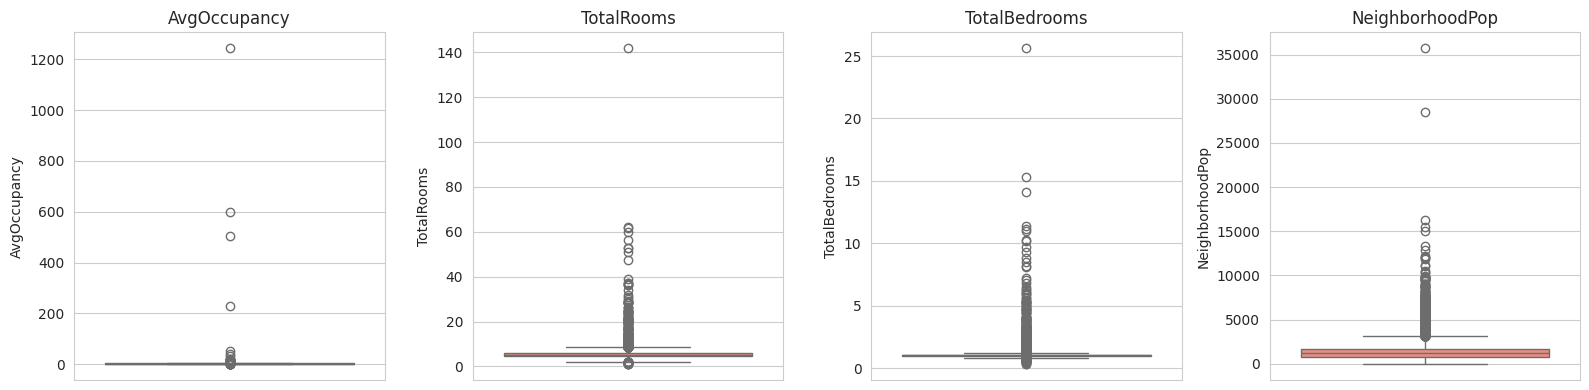

AvgOccupancy: 73 extreme outliers (3×IQR rule)
TotalRooms: 145 extreme outliers (3×IQR rule)
TotalBedrooms: 570 extreme outliers (3×IQR rule)
NeighborhoodPop: 335 extreme outliers (3×IQR rule)


In [8]:
# ══════════════════════════════════════════════════════════════════
# 6. OUTLIER DETECTION (boxplots)
# ══════════════════════════════════════════════════════════════════
outlier_cols = ["AvgOccupancy", "TotalRooms", "TotalBedrooms", "NeighborhoodPop"]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=train[col], ax=ax, color="salmon")
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in outlier_cols:
    Q1, Q3 = train[col].quantile(0.25), train[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((train[col] < Q1 - 3*IQR) | (train[col] > Q3 + 3*IQR)).sum()
    print(f"{col}: {n_outliers} extreme outliers (3×IQR rule)")

### 💡 Insight — Outlier Detection
The IQR-based check flags a meaningful number of outliers: **`TotalBedrooms` has 570**, **`NeighborhoodPop` has 335**, **`TotalRooms` has 145**, and **`AvgOccupancy` has 73**. `TotalBedrooms` having the most outliers is notable — combined with its near-zero correlation to price, this suggests a chunk of the injected Gaussian noise landed specifically in this feature. These are capped (not removed) to preserve sample size while limiting their influence on the model.

## 7. 📈 Feature Relationships with Target
Scatter plots of key features against `TargetPrice` to visually inspect linear/non-linear relationships and noise levels.

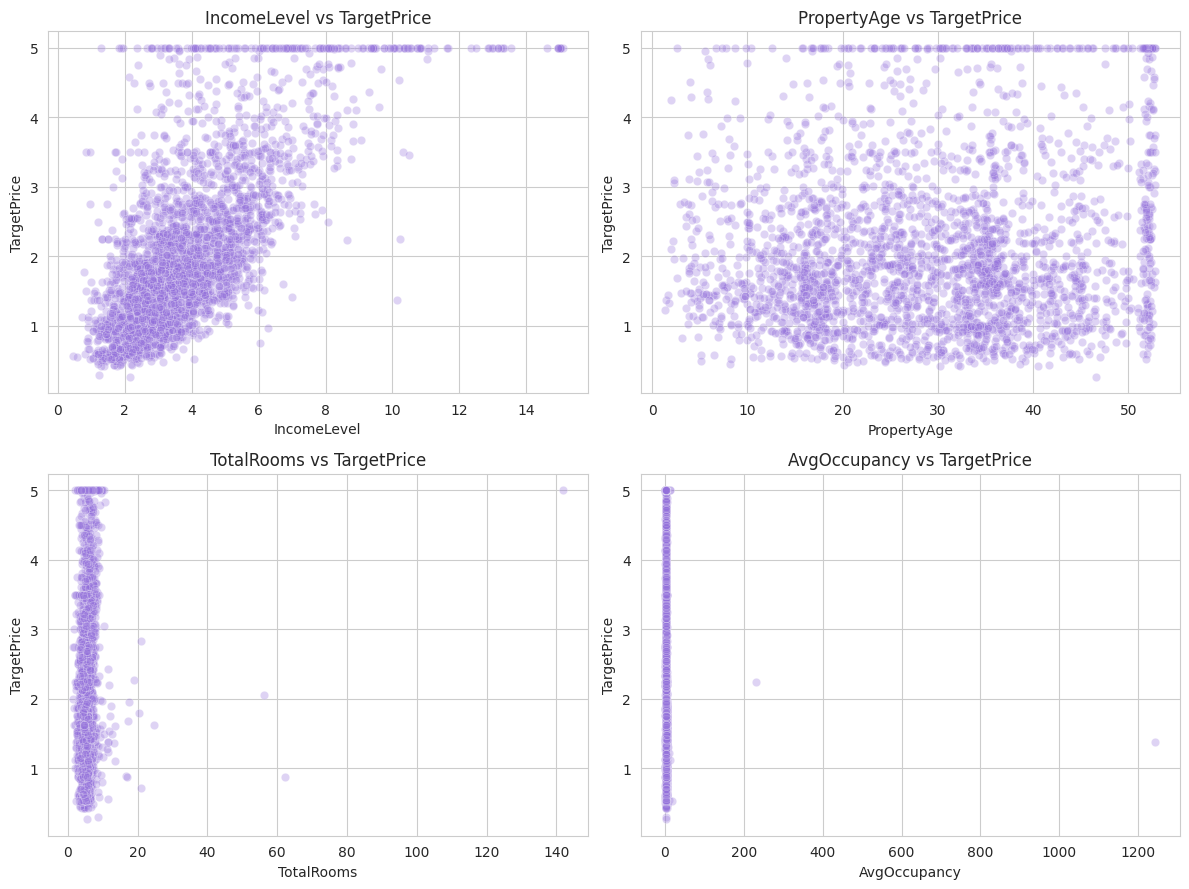

In [9]:
# ══════════════════════════════════════════════════════════════════
# 7. FEATURE RELATIONSHIPS WITH TARGET
# ══════════════════════════════════════════════════════════════════
key_features = ["IncomeLevel", "PropertyAge", "TotalRooms", "AvgOccupancy"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flatten(), key_features):
    sample = train.sample(min(3000, len(train)), random_state=42)  # subsample for speed
    sns.scatterplot(x=sample[col], y=sample[TARGET], alpha=0.3, ax=ax, color="mediumpurple")
    ax.set_title(f"{col} vs {TARGET}")
plt.tight_layout()
plt.show()

## 8. 🛠️ Feature Engineering
Create derived features (density ratios, log transforms, missingness flags) to give the model more predictive signal.

In [10]:
# ══════════════════════════════════════════════════════════════════
# 8. FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════
def add_features(df):
    df = df.copy()
    df["PropertyAge_missing"] = df["PropertyAge"].isnull().astype(int)
    df["PopPerHousehold"] = df["NeighborhoodPop"] / (df["AvgOccupancy"] + 1e-5)
    df["RoomsPerBedroom"] = df["TotalRooms"] / (df["TotalBedrooms"] + 1e-5)
    df["IncomePerRoom"] = df["IncomeLevel"] / (df["TotalRooms"] + 1e-5)
    df["LogPop"] = np.log1p(df["NeighborhoodPop"].clip(lower=0))
    return df

train_fe = add_features(train)
test_fe = add_features(test)

feature_cols = [c for c in train_fe.columns if c not in [TARGET, ID_COL]]
X = train_fe[feature_cols]
y = train_fe[TARGET]
X_test = test_fe[feature_cols]

print(f"\nEngineered features: {[c for c in feature_cols if c not in train.columns]}")


Engineered features: ['PropertyAge_missing', 'PopPerHousehold', 'RoomsPerBedroom', 'IncomePerRoom', 'LogPop']


### 💡 Insight — Feature Engineering
Five features were engineered: `PropertyAge_missing`, `PopPerHousehold`, `RoomsPerBedroom`, `IncomePerRoom`, and `LogPop`. As the feature importance results later confirm, `IncomePerRoom` turns out to be one of the most valuable engineered features — outperforming several raw columns — validating that combining `IncomeLevel` with room count captures signal the raw features alone don't.

## 9. 🔄 Target Transformation & Outlier Capping
Apply log-transform to the target and cap extreme outlier values using the IQR method to improve model robustness.

In [11]:
# ══════════════════════════════════════════════════════════════════
# 9. TARGET TRANSFORM + OUTLIER CAPPING
# ══════════════════════════════════════════════════════════════════
y_log = np.log1p(y.clip(lower=0.01))

for col in outlier_cols:
    Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    X[col] = X[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)


/tmp/ipykernel_16/755763827.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].clip(lower, upper)
/tmp/ipykernel_16/755763827.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].clip(lower, upper)
/tmp/ipykernel_16/755763827.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use